In [ ]:
# --timeframe 1d   : Таймфрейм свечей (дневные данные).
# --start-year 2000: Глубина загрузки истории (начиная с 2000 года).
# --workers 6      : Количество параллельных потоков для ускорения загрузки.

!python -m _tools.update_market_data --timeframe 1d --start-year 2000 --workers 18
!python -m _tools.update_macro --timeframe 1d --start-year 2000 --workers 18
# Выполняет комплексную проверку целостности, отсутствия пропусков и корректности OHLCV данных.
!python -m _tools.check_data_quality

In [ ]:
# --timeframe 1d       : Интервал данных — дневные свечи.
# --lookback 60        : Глубина истории — модель смотрит на 60 дней назад.
# --horizon 10         : Горизонт прогноза — ищем выход по барьерам в течение 10 дней.
# --auto               : Режим автоматического расчета уровней TP/SL на основе волатильности.
# --percentile 75      : Перцентиль волатильности для отсечения аномальных выбросов при авто-разметке.
# --init_split         : Дата начала первого разделения данных на Train и Val.
# --val_interval 2     : Продолжительность валидационного периода в годах.
# --split_interval 2   : Шаг смещения окна Walk-Forward в годах.
# --endpoint           : Дата окончания формирования всех временных интервалов.
# --corr_threshold     : Порог удаления коррелирующих признаков (убираем дубликаты > 85%).
# --cum_threshold      : Порог кумулятивной важности (оставляем топ фичей, дающих 99% влияния).
# --force              : Раскомментируйте параметр ниже для полной перезаписи кэшированных данных.

!python -m _tools.init_dataset \
    --timeframe 1d \
    --lookback 9 \
    --horizon 3 \
    --auto \
    --percentile 75 \
    --init_split 2010-01-01 \
    --val_interval 2 \
    --split_interval 2 \
    --endpoint 2024-01-01 \
    --corr_threshold 0.85 \
    --cum_threshold 0.99

In [ ]:
#полная проверка подготовленных на предыдущем этапе данных
!python -m _tools.verify_data

In [ ]:
#Запуск нескольких процессов в параллели
!./start_swarm.sh

In [ ]:
!python run_walkforward.py \
    --dataset_dir "data/processed/2000_2026_1d_30_5" \
    --bonus_ratio 0.15 \
    --min_delta 0.001 \
    --runs 50 \
    --batch_size 2048 \
    --epochs 100 \
    --l2_reg "1e-3" \
    --lr "8e-2" \
    --start_fold "fold_2010" \
    --append

In [ ]:
#очистка наименне успешных ltsm моделей (остается топ 3)
!python -m _tools.clean_lstm_models

📊 Подключение к базе: data/processed/2000_2026_1d_6_1/fold_2010/trading_factory.db
🧠 Авто-определение хаоса: верхняя граница (valid_max) установлена на 1.2604
--------------------------------------------------
📈 РЕЗУЛЬТАТЫ АНАЛИЗА (Авто-проигнорировано хаоса: 2 ранов):
Теоретический предел Loss (Асимптота): 0.7890
🎯 ПРОГНОЗ: К 40-му рану ожидаемый лучший Loss составит ~0.8138
--------------------------------------------------


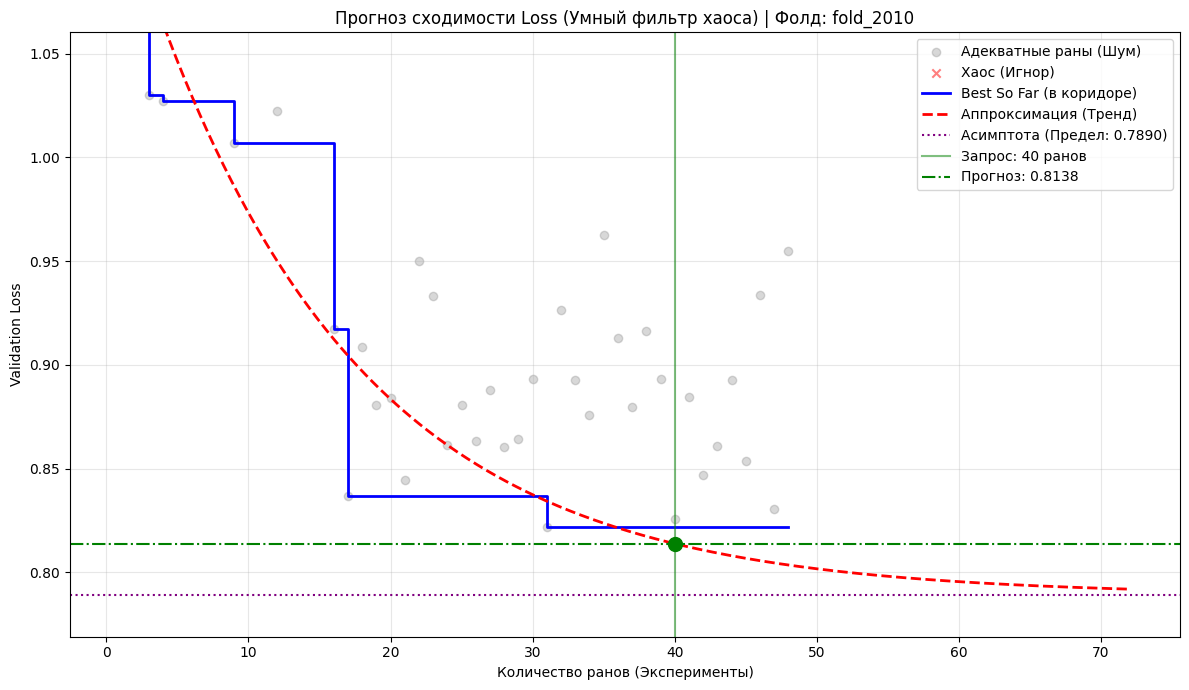

<Figure size 640x480 with 0 Axes>

In [3]:
%matplotlib inline
%run _tools/analyze_runs.py data/processed/2000_2026_1d_6_1/fold_2010 --runs 40

📊 Подключение к базе: data/processed/2000_2026_1d_18_3/fold_2024/trading_factory.db
🧠 Авто-определение хаоса: верхняя граница (valid_max) установлена на 1.0265
--------------------------------------------------
📈 РЕЗУЛЬТАТЫ АНАЛИЗА (Авто-проигнорировано хаоса: 0 ранов):
Теоретический предел Loss (Асимптота): 0.9936
🎯 ПРОГНОЗ: К 30-му рану ожидаемый лучший Loss составит ~0.9936
--------------------------------------------------


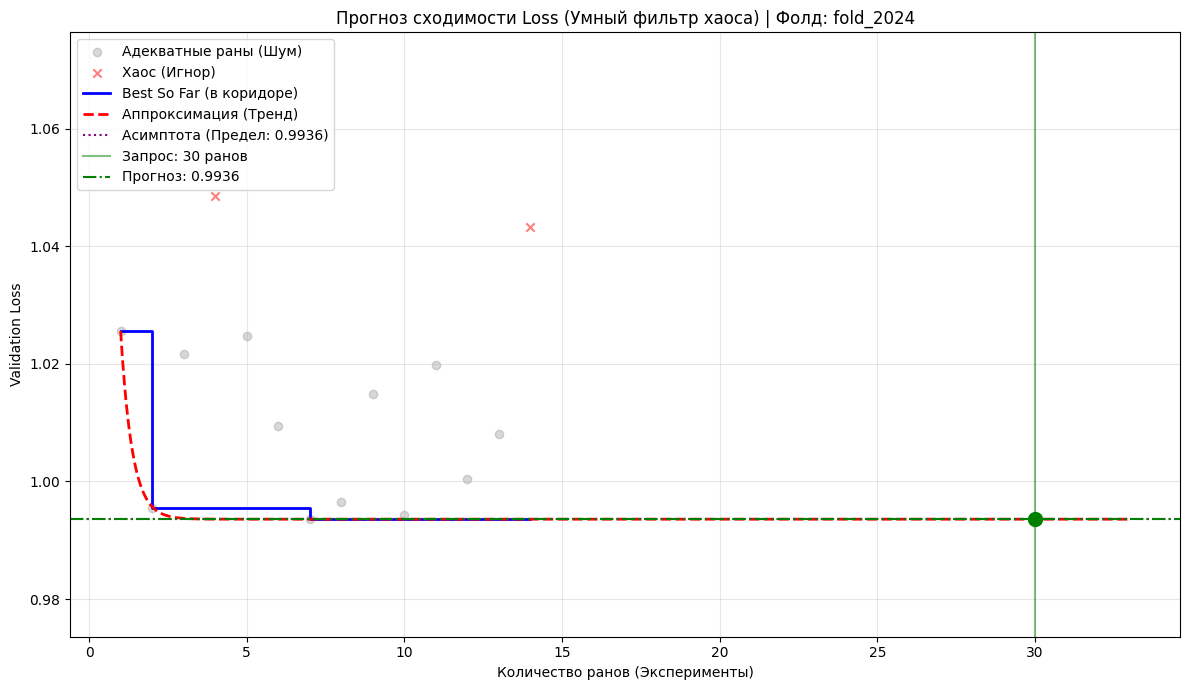

<Figure size 640x480 with 0 Axes>

In [2]:
%matplotlib inline
%run _tools/analyze_runs.py data/processed/2000_2026_1d_18_3/fold_2024 --runs 30

In [ ]:
!python -m _tools.generate_model_specs

In [ ]:
!python -m _tools.prepare_rl_env

In [ ]:
import os
import shutil
from pathlib import Path

# Конфигурация путей
base_dir = Path("/home/restorator/trader_test/data/processed")
dataset_name = "2000_2026_1d_90_15"
source_dir = base_dir / dataset_name
archive_dir = base_dir / "archive" / dataset_name

print(f"🧹 Запуск архивации (Модели + индивидуальные JSON метаданные) для: {dataset_name}...\n")

if not source_dir.exists():
    print(f"❌ Директория не найдена: {source_dir}")
else:
    # Создаем коренную папку архива
    archive_dir.mkdir(parents=True, exist_ok=True)
    
    # Ищем все папки фолдов
    folds = sorted([d for d in source_dir.glob("fold_*") if d.is_dir()])
    
    total_files_moved = 0
    for fold in folds:
        models_dir = fold / "models"
        if not models_dir.exists():
            continue
            
        # Захватываем И модели (.keras), И метаданные (.json)
        files_to_move = list(models_dir.glob("*.keras")) + list(models_dir.glob("*.json"))
        
        if not files_to_move:
            continue
            
        # Создаем папку фолда в архиве
        fold_archive_dir = archive_dir / fold.name
        fold_archive_dir.mkdir(parents=True, exist_ok=True)
        
        # Переносим файлы
        moved_in_fold = 0
        for file_path in files_to_move:
            dest_path = fold_archive_dir / file_path.name
            shutil.move(str(file_path), str(dest_path))
            moved_in_fold += 1
            total_files_moved += 1
            
        print(f"📁 {fold.name}: перенесено файлов (модели и JSON) -> {moved_in_fold}")
        
    print(f"\n✅ Архивация успешно завершена!")
    print(f"📦 Всего перемещено файлов: {total_files_moved}")
    print(f"📂 Место хранения: {archive_dir}")

In [ ]:
import pandas as pd
import numpy as np

# Путь к нашему финальному ансамблю
file_path = "data/processed/2000_2026_1d/rl_env/environment_data.parquet"

print("⏳ Загрузка датасета...")
df = pd.read_parquet(file_path)

print(f"✅ Датасет загружен! Размер: {df.shape[0]} строк, {df.shape[1]} колонок\n")

# 1. Проверка на пропуски (ОЧЕНЬ ВАЖНО из-за пропущенных фолдов)
missing_data = df.isnull().sum()
cols_with_nans = missing_data[missing_data > 0]

if not cols_with_nans.empty:
    print("⚠️ ВНИМАНИЕ! Найдены пропуски (NaN) в колонках:")
    # Выводим топ-10 колонок с наибольшим числом пропусков
    display(cols_with_nans.sort_values(ascending=False).head(10))
    print("\nВозможно, потребуется заполнить их нулями: df.fillna(0, inplace=True)")
else:
    print("✅ Пропусков (NaN) нет! Скрипт ансамбля всё корректно обработал (вероятно, заполнил нулями).")

# 2. Выделяем колонки наших экспертов
expert_cols = [col for col in df.columns if any(prefix in col for prefix in ['c18_', 'c30_', 'c60_', 'rank'])]

print(f"\n🧠 Найдено {len(expert_cols)} колонок от нейросетей-экспертов.")

# 3. Смотрим статистику предсказаний экспертов (чтобы убедиться, что там вероятности от 0 до 1)
if expert_cols:
    print("\n📊 Статистика мнений консилиума (mean, min, max):")
    display(df[expert_cols].describe().T[['mean', 'min', 'max']].head(15))

# 4. Визуальный срез (последние 5 дней)
print("\n👀 Хвост датасета (как это увидит RL-агент на последних шагах):")
# Покажем базовые данные (дата, тикер, цена) и пару колонок экспертов
base_cols = [c for c in ['datetime', 'ticker', 'close', 'label'] if c in df.columns]
cols_to_show = base_cols + expert_cols[:5] 
display(df[cols_to_show].tail())

In [ ]:
!python -m _tools.train_rllib_pbt --population 6 --iterations 3000 --force

In [ ]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ray.rllib.algorithms.algorithm import Algorithm
from ray.tune.registry import register_env

# 1. Указываем Python, где искать класс твоей среды
sys.path.append(os.path.abspath('_tools'))

# 2. ИМПОРТ ТВОЕЙ СРЕДЫ
# Убедись, что файл называется train_rllib_pbt.py и класс называется TradingEnv
from train_rllib_pbt import TradingEnv 


def env_creator(env_config):
    # ИСПРАВЛЕНО: Распаковываем словарь, как этого ожидает твой класс
    return TradingEnv(**env_config)

def main():
    # === РЕГИСТРАЦИЯ СРЕДЫ ===
    # Обязательно делаем это ДО загрузки чекпоинта!
    register_env("TradingEnv-v0", env_creator)
    
    # 3. Автоматический поиск свежего чекпоинта
    base_dir = "data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot"
    
    # Ищем Trial 00004 (он показал +8% на тесте)
    trial_id = "00004" 
    trial_folders = glob.glob(f"{base_dir}/*_{trial_id}_*")

    if not trial_folders:
        raise FileNotFoundError(f"❌ Папка для Trial {trial_id} не найдена в {base_dir}!")

    trial_dir = trial_folders[0]

    # Ищем все чекпоинты внутри этой папки
    checkpoints = sorted(glob.glob(f"{trial_dir}/checkpoint_*"))

    if not checkpoints:
        raise FileNotFoundError(f"❌ В папке {trial_dir} нет сохраненных чекпоинтов!")

    # Берем самый последний (с максимальным номером) и делаем путь АБСОЛЮТНЫМ!
    CHECKPOINT_PATH = os.path.abspath(checkpoints[-1])
    print(f"✅ Найден чекпоинт:\n{CHECKPOINT_PATH}\n")

    # 4. Загрузка алгоритма
    print("⏳ Загрузка агента (это может занять около минуты)...")
    algo = Algorithm.from_checkpoint(CHECKPOINT_PATH)
    print("✅ Агент успешно загружен!")

    # 5. Инициализация среды строго в режиме TEST (экзамен 2022-2024)
    env_config = {
        "data_path": "data/processed/2000_2026_1d/rl_env/environment_data.parquet",
        "split_mode": "test", 
        "initial_balance": 100000.0,
        "commission": 0.0003,
        "max_episode_steps": 252 
    }
    
    # Создаем локальный экземпляр среды
    # ИСПРАВЛЕНО: Распаковываем словарь
    env = TradingEnv(**env_config)
    
    # 6. Прогон агента (Rollout)
    obs, info = env.reset()
    terminated = truncated = False
    history = []

    print("🤖 Агент начинает торговлю на тестовых данных...")
    
    while not (terminated or truncated):
        # Агент принимает детерминированное решение (explore=False) - строго то, чему научился
        action = algo.compute_single_action(obs, explore=False)
        
        # Делаем шаг в среде
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # Сохраняем историю для графиков
        history.append({
            'step': getattr(env, 'current_step', len(history)),
            'price': info.get('current_price', 0),
            'action': action,
            'balance': info.get('portfolio_value', 0),
            'reward': reward
        })
        
        obs = next_obs

    df_history = pd.DataFrame(history)
    print(f"\n🎉 Бэктест завершен! Итоговый баланс: ${df_history['balance'].iloc[-1]:.2f}")

    # ==========================================
    # 7. ВИЗУАЛИЗАЦИЯ: Графики цены и эквити
    # ==========================================
    print("📈 Построение графика...")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]})

    # График цены
    ax1.plot(df_history['step'], df_history['price'], label='Цена актива', color='black', alpha=0.6)

    # Точки входа и выхода. 
    # ВНИМАНИЕ: Проверь логику своей среды! Здесь предполагается: 1 = Покупка, 2 = Продажа.
    buys = df_history[df_history['action'] == 1]
    sells = df_history[df_history['action'] == 2]

    ax1.scatter(buys['step'], buys['price'], marker='^', color='green', s=100, label='Покупка (Buy)', zorder=5)
    ax1.scatter(sells['step'], sells['price'], marker='v', color='red', s=100, label='Продажа (Sell)', zorder=5)

    ax1.set_title(f"Сделки RL-агента (Trial {trial_id}) на тестовых данных (2022-2024)")
    ax1.set_ylabel("Цена актива")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График кривой доходности (Эквити)
    ax2.plot(df_history['step'], df_history['balance'], label='Кривая баланса (Equity)', color='blue', linewidth=2)
    ax2.axhline(y=100000.0, color='red', linestyle='--', alpha=0.5, label='Стартовый баланс') 
    
    ax2.set_ylabel("Баланс ($)")
    ax2.set_xlabel("Шаг среды")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()